<a href="https://colab.research.google.com/github/codemiitkumar/AAI-501-Group-3-EV-Charging-And-Revenue-Optimization/blob/main/EV_Charging_Patterns_and_Revenue_Optimisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Smart EV Charging: Demand Prediction, Dynamic Pricing, and Charging Schedule Optimization

## AAI-501 Final Project
### Group 3

This notebook predicts EV charging demand, groups users by charging behavior, and works out a charging
schedule that makes more money than just charging everyone the moment they plug in.

The dataset does not include electricity prices, customer prices, battery charge level, or how flexible
a driver is about when they leave. Those pieces are added as clearly-labeled assumptions in the pricing
and scheduling sections below, rather than pretending they come from real data.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
warnings.filterwarnings("ignore")

## 1. Import Data File

In [3]:
OUTPUT_DIR = Path("ev_project_output")
OUTPUT_DIR.mkdir(exist_ok=True)

In [4]:
RANDOM_STATE = 42

In [5]:
# Look for the CSV next to this notebook first, then fall back to
# the known upload locations (Colab, or this machine).
candidate_paths = [
    Path("ChargingRecords.csv"),
    Path("/content/ChargingRecords.csv"),
    Path(r"C:\Users\autho\Downloads\Compressed\22495141\ChargingRecords.csv"),
]
DATA_PATH = next(p for p in candidate_paths if p.exists())

In [6]:
df = pd.read_csv(DATA_PATH)

In [7]:
df.head()

,UserID,ChargerID,ChargerCompany,Location,ChargerType,StartDay,StartTime,EndDay,EndTime,StartDatetime,EndDatetime,Duration,Demand
0,0,1,1,hotel,0,2022-09-15,20:54:02,2022-09-15,23:59:13,2022-09-15 20:54,2022-09-15 23:59,185,20.36
1,0,1,1,hotel,0,2022-09-14,20:01:05,2022-09-14,21:31:04,2022-09-14 20:01,2022-09-14 21:31,90,10.19
2,0,1,1,hotel,0,2022-09-14,18:54:30,2022-09-14,19:54:29,2022-09-14 18:54,2022-09-14 19:54,60,6.78
3,0,1,1,hotel,0,2022-09-29,18:32:51,2022-09-30,0:16:42,2022-09-29 18:32,2022-09-30 0:16,344,37.65
4,0,1,1,hotel,0,2022-09-25,19:30:15,2022-09-26,0:30:14,2022-09-25 19:30,2022-09-26 0:30,300,33.81


In [8]:
print(f"Rows: {len(df):,}")

Rows: 72,856


In [9]:
print(f"Columns: {len(df.columns)}")

Columns: 13


In [10]:
print("Columns:")
print(df.columns.tolist())

Columns:
['UserID', 'ChargerID', 'ChargerCompany', 'Location', 'ChargerType', 'StartDay', 'StartTime', 'EndDay', 'EndTime', 'StartDatetime', 'EndDatetime', 'Duration', 'Demand']


## 2. Data Cleaning

In [11]:
# Strip stray whitespace from column names.
df.columns = [c.strip() for c in df.columns]

In [12]:
df["StartDatetime"] = pd.to_datetime(
    df["StartDatetime"], errors="coerce"
)

In [13]:
df["EndDatetime"] = pd.to_datetime(
    df["EndDatetime"], errors="coerce"
)

Make sure ID and measurement columns are actually numbers.

In [14]:
numeric_columns = [
    "UserID",
    "ChargerID",
    "ChargerCompany",
    "ChargerType",
    "Duration",
    "Demand",
]

In [15]:
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

Drop exact duplicate rows.

In [16]:
before = len(df)

In [17]:
df = df.drop_duplicates().copy()

In [18]:
print(f"Exact duplicates removed: {before - len(df):,}")

Exact duplicates removed: 13


Drop rows missing anything we can't work without.

In [19]:
essential = [
    "UserID",
    "ChargerID",
    "Location",
    "ChargerType",
    "StartDatetime",
    "EndDatetime",
    "Duration",
    "Demand",
]

In [20]:
before = len(df)

In [21]:
df = df.dropna(subset=essential).copy()

In [22]:
print(f"Rows removed for missing essential values: {before - len(df):,}")

Rows removed for missing essential values: 0


In [23]:
len(df)

72843

Recalculate the actual session duration from the timestamps, since the raw `Duration` column can disagree with them.

In [24]:
df["CalculatedDuration"] = (
    df["EndDatetime"] - df["StartDatetime"]
).dt.total_seconds() / 60

See how far the reported duration drifts from the timestamp-based one.

In [25]:
df["DurationDifference"] = (
    df["Duration"] - df["CalculatedDuration"]
).abs()

Keep only sessions that make physical sense: end after start, positive duration, positive demand.

In [26]:
valid_mask = (
    (df["EndDatetime"] > df["StartDatetime"])
    & (df["CalculatedDuration"] > 0)
    & (df["Demand"] > 0)
)

In [27]:
invalid_count = (~valid_mask).sum()

In [28]:
print(f"Invalid timestamp/demand rows removed: {invalid_count:,}")

Invalid timestamp/demand rows removed: 547


In [29]:
df = df.loc[valid_mask].copy()

Use the timestamp-based duration from here on, since it's the internally consistent one.

In [30]:
df["Duration"] = df["CalculatedDuration"]

Quick sanity check on the cleaned numbers.

In [31]:
print("Cleaned descriptive statistics:")
print(
    df[["Duration", "Demand"]]
    .describe()
    .round(2)
)

Cleaned descriptive statistics:
       Duration    Demand
count  72296.00  72296.00
mean     156.68     17.56
std      159.20     13.46
min        1.00      0.01
25%       41.00      7.68
50%      115.00     14.25
75%      205.00     23.20
max     4717.00     97.00


In [32]:
print("Final cleaned shape:", df.shape)

Final cleaned shape: (72296, 15)


In [33]:
df.to_csv(OUTPUT_DIR / "cleaned_charging_records.csv", index=False)

## 3. Feature Engineering

Break each session's start time into the calendar fields we'll need for grouping and modeling.

In [34]:
df["Date"] = df["StartDatetime"].dt.date

In [35]:
df["Hour"] = df["StartDatetime"].dt.hour

In [36]:
df["DayOfWeek"] = df["StartDatetime"].dt.dayofweek

In [37]:
df["DayName"] = df["StartDatetime"].dt.day_name()

In [38]:
df["Month"] = df["StartDatetime"].dt.month

In [39]:
df["WeekOfYear"] = df["StartDatetime"].dt.isocalendar().week.astype(int)

In [40]:
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)

Estimate the average charging power of each session (energy delivered divided by time taken).

In [41]:
df["AveragePowerKW"] = df["Demand"] / (df["Duration"] / 60)

A few sessions have near-zero duration, which blows up to infinity here, so drop those.

In [42]:
df["AveragePowerKW"] = df["AveragePowerKW"].replace(
    [np.inf, -np.inf], np.nan
)

In [43]:
df = df.dropna(subset=["AveragePowerKW"]).copy()

## 4. Data Visualization

How many sessions start in each hour of the day.

In [44]:
hourly_sessions = df.groupby("Hour").size()

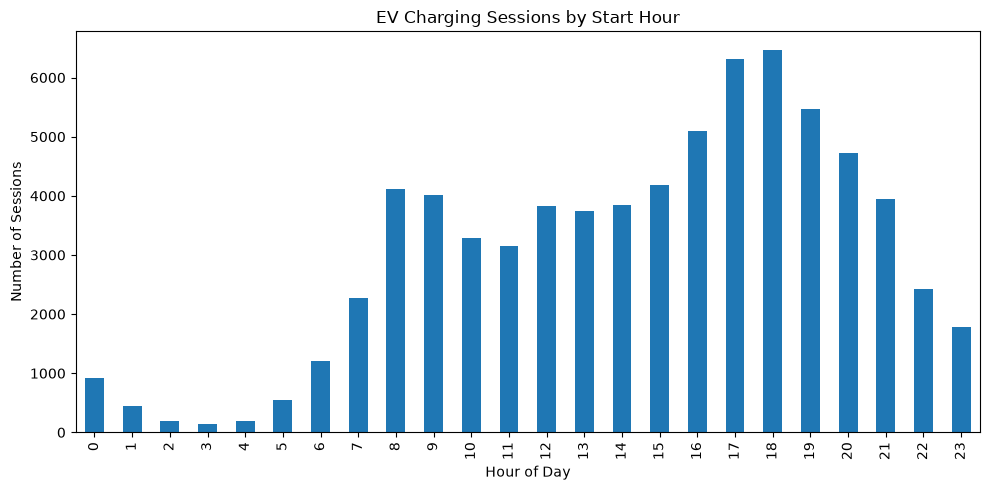

In [45]:
plt.figure(figsize=(10, 5))
hourly_sessions.plot(kind="bar")
plt.title("EV Charging Sessions by Start Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Sessions")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_sessions_by_hour.png", dpi=200)
plt.show()

Total energy pulled from the grid in each hour of the day.

In [46]:
hourly_demand = df.groupby("Hour")["Demand"].sum()

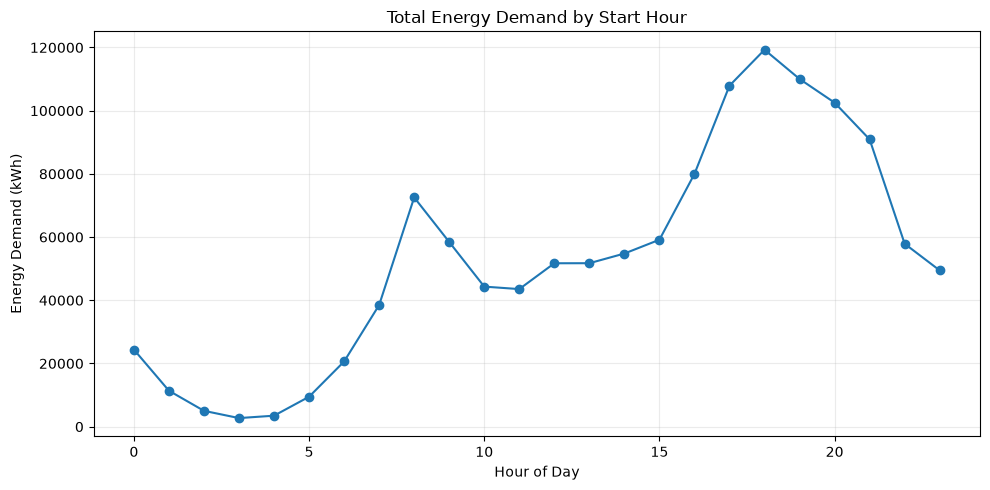

In [47]:
plt.figure(figsize=(10, 5))
hourly_demand.plot(kind="line", marker="o")
plt.title("Total Energy Demand by Start Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Energy Demand (kWh)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_demand_by_hour.png", dpi=200)
plt.show()

Spread of how much energy a single session uses.

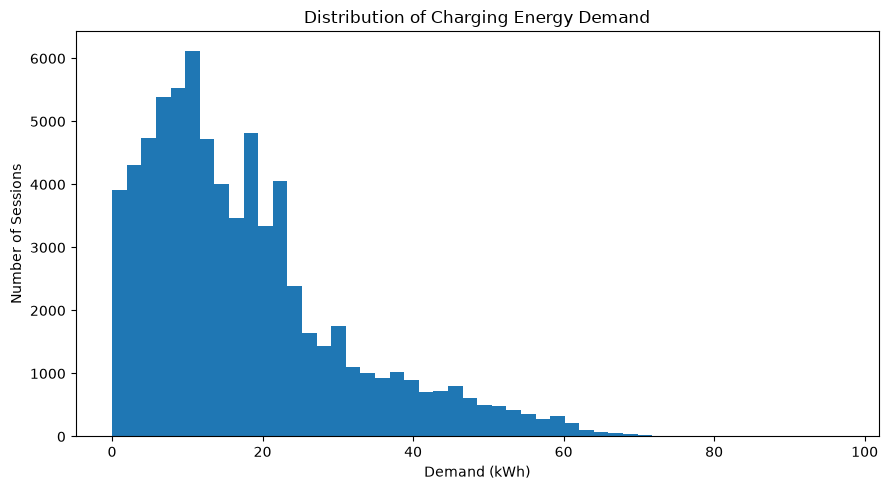

In [48]:
plt.figure(figsize=(9, 5))
plt.hist(df["Demand"], bins=50)
plt.title("Distribution of Charging Energy Demand")
plt.xlabel("Demand (kWh)")
plt.ylabel("Number of Sessions")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_demand_distribution.png", dpi=200)
plt.show()

Which locations draw the most total energy.

In [49]:
location_demand = (
    df.groupby("Location")["Demand"]
    .sum()
    .sort_values(ascending=False)
)

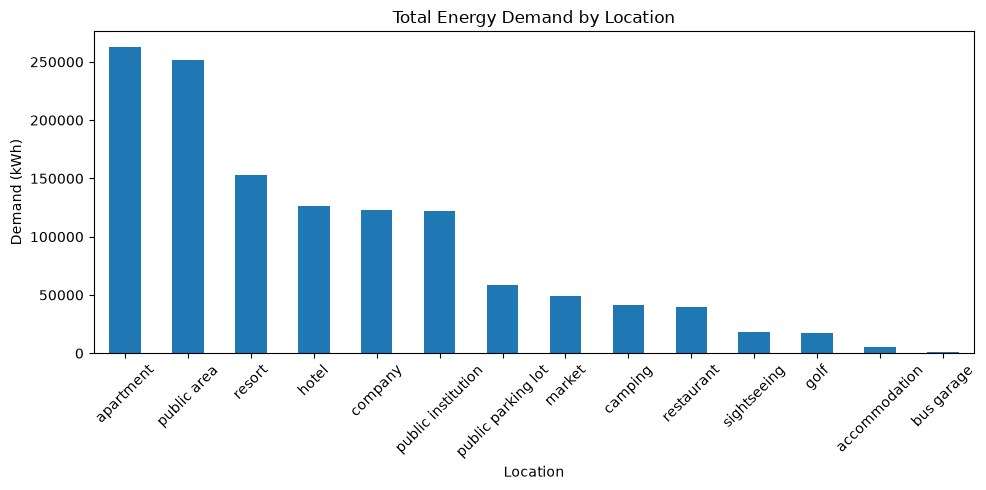

In [50]:
plt.figure(figsize=(10, 5))
location_demand.plot(kind="bar")
plt.title("Total Energy Demand by Location")
plt.xlabel("Location")
plt.ylabel("Demand (kWh)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_location_demand.png", dpi=200)
plt.show()

Average demand per session, by day of the week.

In [51]:
weekday_demand = (
    df.groupby("DayName")["Demand"]
    .mean()
    .reindex(
        [
            "Monday",
            "Tuesday",
            "Wednesday",
            "Thursday",
            "Friday",
            "Saturday",
            "Sunday",
        ]
    )
)

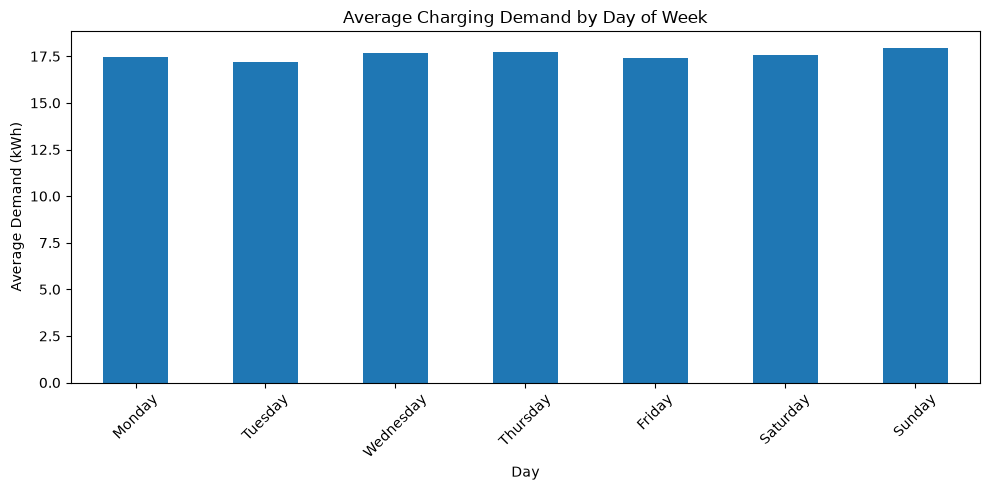

In [52]:
plt.figure(figsize=(10, 5))
weekday_demand.plot(kind="bar")
plt.title("Average Charging Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Demand (kWh)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_weekday_demand.png", dpi=200)
plt.show()

## 5. Building the Hourly Time Series

Collapse individual sessions into one row per hour.

In [53]:
hourly = (
    df.set_index("StartDatetime")
    .resample("1h")
    .agg(
        TotalDemand=("Demand", "sum"),
        SessionCount=("Demand", "count"),
        AverageDemand=("Demand", "mean"),
        AverageDuration=("Duration", "mean"),
    )
    .fillna(0)
)

Add "lag" columns so each row also knows what demand looked like in recent past hours.
That's what turns this into a supervised forecasting problem a regression model can learn from.

In [54]:
hourly["Lag1"] = hourly["TotalDemand"].shift(1)

In [55]:
hourly["Lag2"] = hourly["TotalDemand"].shift(2)

In [56]:
hourly["Lag3"] = hourly["TotalDemand"].shift(3)

In [57]:
hourly["Lag24"] = hourly["TotalDemand"].shift(24)  # same hour, one day ago

In [58]:
hourly["Lag168"] = hourly["TotalDemand"].shift(168)  # same hour, one week ago

In [59]:
hourly["Rolling24"] = (
    hourly["TotalDemand"]
    .shift(1)
    .rolling(24)
    .mean()
)

In [60]:
hourly["Hour"] = hourly.index.hour

In [61]:
hourly["DayOfWeek"] = hourly.index.dayofweek

In [62]:
hourly["IsWeekend"] = (hourly["DayOfWeek"] >= 5).astype(int)

The first week has no lag history yet, so drop those rows.

In [63]:
hourly = hourly.dropna().copy()

Split by time rather than randomly, so the model is always trained on the past and tested on the
future -- the same way it would be used in practice.

In [64]:
split_index = int(len(hourly) * 0.80)

In [65]:
train_ts = hourly.iloc[:split_index].copy()

In [66]:
test_ts = hourly.iloc[split_index:].copy()

In [67]:
ts_features = [
    "Lag1",
    "Lag2",
    "Lag3",
    "Lag24",
    "Lag168",
    "Rolling24",
    "Hour",
    "DayOfWeek",
    "IsWeekend",
]

In [68]:
X_train_ts = train_ts[ts_features]

In [69]:
y_train_ts = train_ts["TotalDemand"]

In [70]:
X_test_ts = test_ts[ts_features]

In [71]:
y_test_ts = test_ts["TotalDemand"]

In [72]:
print("Time-series observations:", len(hourly))

Time-series observations: 8599


In [73]:
print("Training observations:", len(train_ts))

Training observations: 6879


In [74]:
print("Testing observations:", len(test_ts))

Testing observations: 1720


## 6. Time-Series / Regression Model Comparison

In [75]:
time_series_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=10,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=150,
        max_depth=15,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=150,
        max_depth=3,
        learning_rate=0.05,
        random_state=RANDOM_STATE
    ),
}

In [76]:
model_results = []

In [77]:
predictions = {}

Train each model on the training hours, then score it on the held-out test hours it has never seen.

In [78]:
for name, model in time_series_models.items():
    model.fit(X_train_ts, y_train_ts)
    pred = model.predict(X_test_ts)

    predictions[name] = pred

    mae = mean_absolute_error(y_test_ts, pred)
    rmse = np.sqrt(mean_squared_error(y_test_ts, pred))
    r2 = r2_score(y_test_ts, pred)

    model_results.append(
        {
            "Model": name,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
        }
    )

In [79]:
results_df = pd.DataFrame(model_results).sort_values("RMSE")

In [80]:
print(results_df.round(3).to_string(index=False))

            Model    MAE   RMSE    R2
    Random Forest 57.815 78.956 0.673
Gradient Boosting 57.382 79.437 0.669
Linear Regression 61.650 83.697 0.633
    Decision Tree 65.055 89.850 0.577


In [81]:
results_df.to_csv(
    OUTPUT_DIR / "regression_model_comparison.csv",
    index=False
)

Chart the four models side by side so the RMSE gap is easy to see.

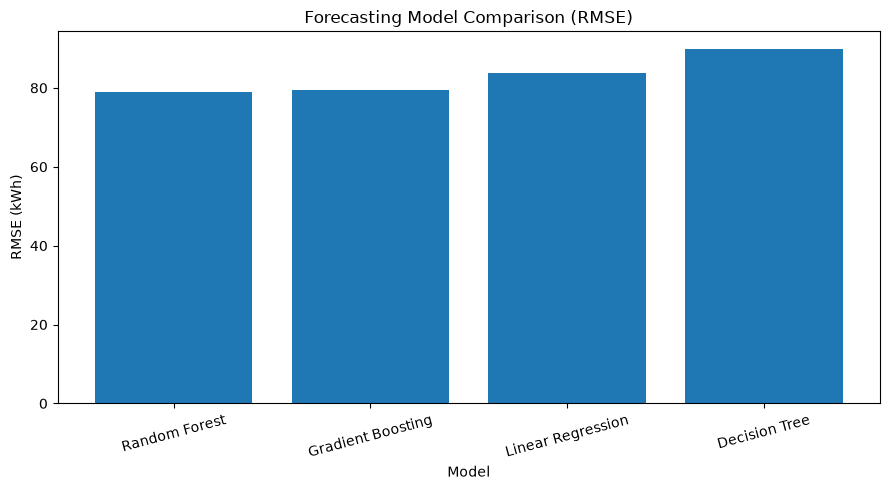

In [82]:
plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Forecasting Model Comparison (RMSE)")
plt.xlabel("Model")
plt.ylabel("RMSE (kWh)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "09_model_rmse_comparison.png", dpi=200)
plt.show()

Plot actual demand against the best-performing model's predictions.

In [83]:
best_model_name = results_df.iloc[0]["Model"]

In [84]:
best_prediction = predictions[best_model_name]

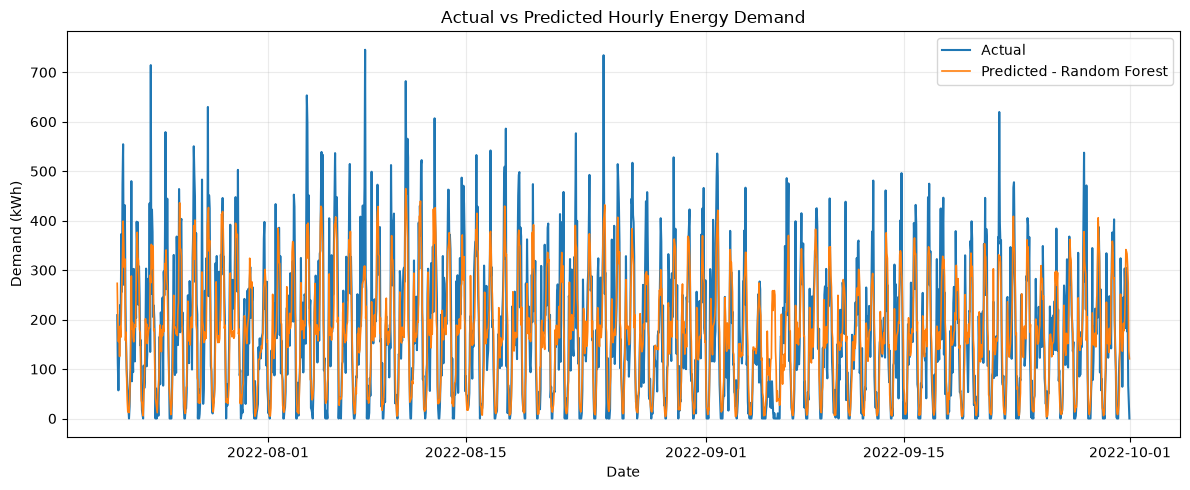

In [85]:
plt.figure(figsize=(12, 5))
plt.plot(
    test_ts.index,
    y_test_ts.values,
    label="Actual",
    linewidth=1.5,
)
plt.plot(
    test_ts.index,
    best_prediction,
    label=f"Predicted - {best_model_name}",
    linewidth=1.2,
)
plt.title("Actual vs Predicted Hourly Energy Demand")
plt.xlabel("Date")
plt.ylabel("Demand (kWh)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_actual_vs_predicted.png", dpi=200)
plt.show()

## 7. Forecast Verification Against a Simple Baseline

Naive forecast: assume demand this hour equals demand exactly 24 hours ago. Our trained models
should clearly beat this.

In [86]:
naive_pred = test_ts["Lag24"].values

In [87]:
naive_mae = mean_absolute_error(y_test_ts, naive_pred)

In [88]:
naive_rmse = np.sqrt(mean_squared_error(y_test_ts, naive_pred))

In [89]:
naive_r2 = r2_score(y_test_ts, naive_pred)

In [90]:
baseline_row = pd.DataFrame(
    [
        {
            "Model": "Naive 24-hour baseline",
            "MAE": naive_mae,
            "RMSE": naive_rmse,
            "R2": naive_r2,
        }
    ]
)

In [91]:
all_forecast_results = pd.concat(
    [baseline_row, results_df],
    ignore_index=True,
)

In [92]:
print(all_forecast_results.round(3).to_string(index=False))

                 Model    MAE    RMSE    R2
Naive 24-hour baseline 75.244 104.258 0.430
         Random Forest 57.815  78.956 0.673
     Gradient Boosting 57.382  79.437 0.669
     Linear Regression 61.650  83.697 0.633
         Decision Tree 65.055  89.850 0.577


In [93]:
all_forecast_results.to_csv(
    OUTPUT_DIR / "forecast_verification.csv",
    index=False
)

## 8. K-Means User Behavior Clustering

`UserID = 0` isn't a real customer -- it's how the dataset marks everyone who isn't signed up with the
charging company, so it lumps together thousands of different people under one ID. Left in, it would form
its own giant "user" that skews the clustering, so it's excluded here and analyzed only as part of the
system-wide demand totals earlier in this notebook.

In [94]:
df_clustering = df[df["UserID"] != 0].copy()

Summarize each user's charging habits into a single row of features.

In [95]:
user_features = (
    df_clustering.groupby("UserID")
    .agg(
        Sessions=("UserID", "size"),
        TotalDemand=("Demand", "sum"),
        AverageDemand=("Demand", "mean"),
        AverageDuration=("Duration", "mean"),
        AverageStartHour=("Hour", "mean"),
        WeekendShare=("IsWeekend", "mean"),
    )
    .copy()
)

In [96]:
cluster_features = [
    "Sessions",
    "TotalDemand",
    "AverageDemand",
    "AverageDuration",
    "AverageStartHour",
    "WeekendShare",
]

Scale features so a big-magnitude one like TotalDemand doesn't dominate the distance calculation just because of its units.

In [97]:
scaler = StandardScaler()

In [98]:
X_cluster = scaler.fit_transform(user_features[cluster_features])

Try a handful of cluster counts and see which one separates users most cleanly (highest silhouette score).

In [99]:
cluster_results = []

In [100]:
for k in range(2, 7):
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20,
    )
    labels = kmeans.fit_predict(X_cluster)

    score = silhouette_score(X_cluster, labels)

    cluster_results.append(
        {
            "K": k,
            "SilhouetteScore": score,
        }
    )

In [101]:
cluster_scores = pd.DataFrame(cluster_results)

In [102]:
best_k = int(
    cluster_scores.loc[
        cluster_scores["SilhouetteScore"].idxmax(),
        "K"
    ]
)

In [103]:
print(cluster_scores.round(4).to_string(index=False))

 K  SilhouetteScore
 2           0.4402
 3           0.3339
 4           0.2753
 5           0.2166
 6           0.2254


In [104]:
print(f"Selected K = {best_k}")

Selected K = 2


In [105]:
final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=20,
)

In [106]:
user_features["Cluster"] = final_kmeans.fit_predict(X_cluster)

In [107]:
cluster_profile = (
    user_features
    .groupby("Cluster")[cluster_features]
    .mean()
    .round(2)
)

In [108]:
print("Cluster profiles:")

Cluster profiles:


In [109]:
print(cluster_profile)

         Sessions  TotalDemand  AverageDemand  AverageDuration  \
Cluster                                                          
0            8.53       142.51          17.58           134.55   
1          109.41      2117.00          22.39           175.08   

         AverageStartHour  WeekendShare  
Cluster                                  
0                   15.01          0.30  
1                   14.42          0.24  


In [110]:
cluster_profile.to_csv(OUTPUT_DIR / "user_cluster_profiles.csv")

In [111]:
user_features.reset_index().to_csv(
    OUTPUT_DIR / "user_clusters.csv",
    index=False
)

<Figure size 800x500 with 0 Axes>

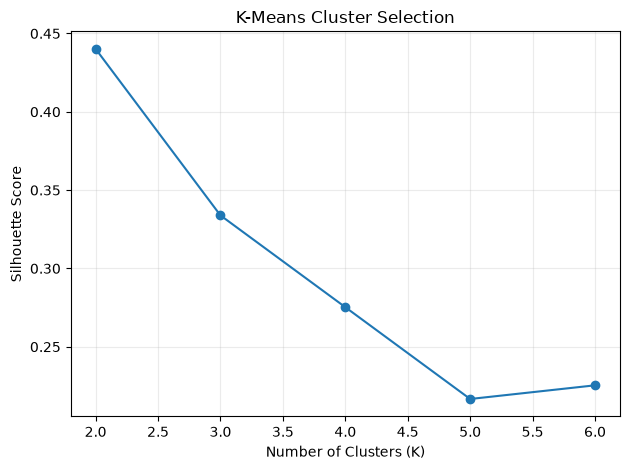

In [112]:
plt.figure(figsize=(8, 5))
cluster_scores.plot(
    x="K",
    y="SilhouetteScore",
    marker="o",
    legend=False,
)
plt.title("K-Means Cluster Selection")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "07_cluster_selection.png", dpi=200)
plt.show()

## 9. Dynamic Pricing Simulation

The dataset has no electricity cost or customer price columns, so the two functions below are our own
transparent modeling assumptions, not values measured from the data.

In [113]:
def electricity_cost(hour):
    """What we assume the grid charges us, per kWh, at this hour."""
    if 0 <= hour < 6:
        return 5.0
    if 6 <= hour < 16:
        return 7.0
    if 16 <= hour < 21:
        return 11.0
    return 7.0

In [114]:
def customer_price(utilization):
    """What we charge the customer, based on how busy the chargers are."""
    if utilization < 0.30:
        return 8.0
    if utilization < 0.60:
        return 10.0
    if utilization < 0.80:
        return 13.0
    return 16.0

Work out how many chargers are in use at any given moment, then turn that into an hourly utilization rate.

In [115]:
unique_chargers = df["ChargerID"].nunique()

In [116]:
events = []

In [117]:
for row in df[
    ["StartDatetime", "EndDatetime"]
].itertuples(index=False):
    events.append((row.StartDatetime, 1))
    events.append((row.EndDatetime, -1))

In [118]:
events_df = pd.DataFrame(events, columns=["Datetime", "Change"])

In [119]:
events_df = (
    events_df.groupby("Datetime")["Change"]
    .sum()
    .sort_index()
    .cumsum()
    .rename("ActiveSessions")
)

In [120]:
utilization_hourly = (
    events_df
    .resample("1h")
    .max()
    .fillna(0)
    .to_frame()
)

In [121]:
utilization_hourly["Utilization"] = (
    utilization_hourly["ActiveSessions"] / unique_chargers
).clip(0, 1)

In [122]:
utilization_hourly["ElectricityCost"] = [
    electricity_cost(h)
    for h in utilization_hourly.index.hour
]

In [123]:
utilization_hourly["CustomerPrice"] = (
    utilization_hourly["Utilization"]
    .apply(customer_price)
)

In [124]:
utilization_hourly["MarginPerKWh"] = (
    utilization_hourly["CustomerPrice"]
    - utilization_hourly["ElectricityCost"]
)

In [125]:
print(
    utilization_hourly[
        [
            "ActiveSessions",
            "Utilization",
            "ElectricityCost",
            "CustomerPrice",
            "MarginPerKWh",
        ]
    ].head(24)
)

                     ActiveSessions  Utilization  ElectricityCost  \
Datetime                                                            
2021-09-30 17:00:00             1.0     0.000473             11.0   
2021-09-30 18:00:00             3.0     0.001418             11.0   
2021-09-30 19:00:00             4.0     0.001890             11.0   
2021-09-30 20:00:00             5.0     0.002363             11.0   
2021-09-30 21:00:00             9.0     0.004253              7.0   
2021-09-30 22:00:00            14.0     0.006616              7.0   
2021-09-30 23:00:00            19.0     0.008979              7.0   
2021-10-01 00:00:00            18.0     0.008507              5.0   
2021-10-01 01:00:00            14.0     0.006616              5.0   
2021-10-01 02:00:00            12.0     0.005671              5.0   
2021-10-01 03:00:00             7.0     0.003308              5.0   
2021-10-01 04:00:00             5.0     0.002363              5.0   
2021-10-01 05:00:00             6.

In [126]:
utilization_hourly.to_csv(OUTPUT_DIR / "dynamic_pricing_simulation.csv")

## 10. Charging Schedule Optimization

This section uses a mixed-integer linear program (MILP) to decide *when*, within each driver's
available window, to actually charge them so total profit is highest -- instead of just charging
everyone the moment they plug in.

In [127]:
from scipy.optimize import milp, LinearConstraint, Bounds
from scipy.sparse import lil_matrix

In [128]:
def build_synthetic_schedule_sessions(
    source_df,
    number_of_sessions=30,
    seed=42,
):
    """
    Take real historical sessions from the held-out period and treat
    each one's actual start/end time as the driver's available
    charging window.

    This is a simulation assumption: the dataset has no explicit
    departure deadline or flexibility field, so we reuse the real
    session window as a stand-in for it.
    """
    sample = source_df.sample(
        n=min(number_of_sessions, len(source_df)),
        random_state=seed,
    ).copy()

    # Round each session's window out to whole hours.
    sample["ArrivalHour"] = sample["StartDatetime"].dt.floor("h")
    sample["DepartureHour"] = sample["EndDatetime"].dt.ceil("h")

    # Every window needs to be at least one hour long.
    sample["DepartureHour"] = np.maximum(
        sample["DepartureHour"].values.astype("datetime64[ns]"),
        (
            sample["ArrivalHour"] + pd.Timedelta(hours=1)
        ).values.astype("datetime64[ns]"),
    )

    sample["EnergyRequired"] = sample["Demand"].clip(lower=1.0)

    # Use the session's historical average power as its assumed
    # charging rate, capped at a realistic charger limit.
    sample["PowerKW"] = (
        sample["Demand"] / (sample["Duration"] / 60)
    ).clip(lower=1.0, upper=22.0)

    # Capping the power above can make a session need more hours than
    # its original window allows (the real session may have charged
    # faster than our assumed cap). Stretch the window so every
    # session always has enough time to receive its required energy.
    required_hours = np.ceil(
        sample["EnergyRequired"] / sample["PowerKW"]
    )
    sample["DepartureHour"] = np.maximum(
        sample["DepartureHour"].values.astype("datetime64[ns]"),
        (
            sample["ArrivalHour"]
            + pd.to_timedelta(required_hours, unit="h")
        ).values.astype("datetime64[ns]"),
    )

    sample["SessionID"] = np.arange(len(sample))

    return sample

In [129]:
def optimize_charging_schedule(
    sessions,
    slot_hours=1,
    grid_limit_kw=150.0,
):
    """
    Decide which hourly slot(s) each session should charge in.

    Decision variable:
        x[i, t] = 1 if session i charges during hour slot t.

    Objective:
        Maximize estimated charging profit.

    Constraints:
        1. Every EV gets exactly the number of hours it needs.
        2. Charging can only happen inside that EV's available window.
        3. Total power drawn at any one hour stays under the grid limit.

    This is a simplified, one-hour-block model meant to illustrate the
    idea, not a production charger controller.
    """

    if sessions.empty:
        return None

    # Build one global list of hourly slots covering every session.
    start = sessions["ArrivalHour"].min()
    end = sessions["DepartureHour"].max()

    slots = pd.date_range(
        start=start,
        end=end - pd.Timedelta(hours=1),
        freq="1h",
    )

    n_sessions = len(sessions)
    n_slots = len(slots)

    # One decision variable per (session, slot) pair.
    n_vars = n_sessions * n_slots

    objective = np.zeros(n_vars)
    integrality = np.ones(n_vars)
    lower_bounds = np.zeros(n_vars)
    upper_bounds = np.ones(n_vars)

    def idx(i, t):
        return i * n_slots + t

    # Objective: profit (customer price minus electricity cost) for
    # every hour a session could charge in.
    for i, session in enumerate(
        sessions.itertuples(index=False)
    ):
        for t, slot in enumerate(slots):
            variable_index = idx(i, t)

            available = (
                slot >= session.ArrivalHour
                and slot < session.DepartureHour
            )

            if not available:
                upper_bounds[variable_index] = 0

            cost = electricity_cost(slot.hour)
            price = customer_price(0.50)  # neutral baseline price
            margin = price - cost

            energy = session.PowerKW * slot_hours
            objective[variable_index] = -margin * energy

    constraints = []
    lower = []
    upper = []

    # Each session must charge for exactly the number of hours it needs.
    for i, session in enumerate(
        sessions.itertuples(index=False)
    ):
        required_hours = int(
            np.ceil(
                session.EnergyRequired / session.PowerKW
            )
        )

        row = lil_matrix((1, n_vars))
        for t in range(n_slots):
            row[0, idx(i, t)] = 1

        constraints.append(row.tocsr())
        lower.append(required_hours)
        upper.append(required_hours)

    # Total power drawn each hour can't exceed the grid limit.
    for t in range(n_slots):
        row = lil_matrix((1, n_vars))

        for i, session in enumerate(
            sessions.itertuples(index=False)
        ):
            row[0, idx(i, t)] = session.PowerKW

        constraints.append(row.tocsr())
        lower.append(-np.inf)
        upper.append(grid_limit_kw)

    A = lil_matrix((len(constraints), n_vars))

    for r, row in enumerate(constraints):
        A[r, :] = row

    linear_constraint = LinearConstraint(
        A.tocsr(),
        np.array(lower),
        np.array(upper),
    )

    result = milp(
        c=objective,
        integrality=integrality,
        bounds=Bounds(lower_bounds, upper_bounds),
        constraints=linear_constraint,
        options={"time_limit": 60},
    )

    if not result.success:
        print("Optimization did not reach an optimal solution:")
        print(result.message)
        return None

    x = result.x.reshape(n_sessions, n_slots)

    schedule_rows = []

    for i, session in enumerate(
        sessions.itertuples(index=False)
    ):
        selected = np.where(x[i] > 0.5)[0]

        for t in selected:
            slot = slots[t]
            energy = session.PowerKW * slot_hours
            cost = electricity_cost(slot.hour)
            price = customer_price(0.50)

            schedule_rows.append(
                {
                    "SessionID": session.SessionID,
                    "UserID": session.UserID,
                    "ChargerID": session.ChargerID,
                    "ScheduledSlot": slot,
                    "EnergyKWh": energy,
                    "ElectricityCostPerKWh": cost,
                    "CustomerPricePerKWh": price,
                    "EstimatedRevenue": price * energy,
                    "EstimatedCost": cost * energy,
                    "EstimatedProfit": (price - cost) * energy,
                }
            )

    return pd.DataFrame(schedule_rows)

Use the chronological test period so this simulation doesn't reuse any data the forecasting models were trained on.

In [130]:
simulation_source = df[
    df["StartDatetime"] >= test_ts.index.min()
].copy()

Keep a manageable sample of sessions for the MILP to solve.

In [131]:
simulation_sessions = build_synthetic_schedule_sessions(
    simulation_source,
    number_of_sessions=30,
    seed=RANDOM_STATE,
)

In [132]:
GRID_LIMIT_KW = 150.0  # assumed max simultaneous charging power for this site

In [133]:
optimized_schedule = optimize_charging_schedule(
    simulation_sessions,
    slot_hours=1,
    grid_limit_kw=GRID_LIMIT_KW,
)

In [134]:
if optimized_schedule is not None:
    optimized_schedule.to_csv(
        OUTPUT_DIR / "optimized_charging_schedule.csv",
        index=False,
    )

    print("Optimized schedule:")
    print(optimized_schedule.head(20).to_string(index=False))

Optimized schedule:
 SessionID  UserID  ChargerID       ScheduledSlot  EnergyKWh  ElectricityCostPerKWh  CustomerPricePerKWh  EstimatedRevenue  EstimatedCost  EstimatedProfit
         0     235        170 2022-09-27 13:00:00   6.765625                    7.0                 10.0         67.656250      47.359375        20.296875
         0     235        170 2022-09-27 14:00:00   6.765625                    7.0                 10.0         67.656250      47.359375        20.296875
         0     235        170 2022-09-27 15:00:00   6.765625                    7.0                 10.0         67.656250      47.359375        20.296875
         0     235        170 2022-09-27 16:00:00   6.765625                   11.0                 10.0         67.656250      74.421875        -6.765625
         0     235        170 2022-09-27 17:00:00   6.765625                   11.0                 10.0         67.656250      74.421875        -6.765625
         0     235        170 2022-09-27 18:00:00 

## 11. Baseline vs Optimized Verification

In [135]:
def calculate_baseline(sessions):
    """
    Baseline policy: charge immediately at the start of each driver's
    available window. Deliberately simple, so it's an honest
    benchmark for the optimizer to beat.
    """
    rows = []

    for session in sessions.itertuples(index=False):
        required_hours = int(
            np.ceil(
                session.EnergyRequired / session.PowerKW
            )
        )

        for h in range(required_hours):
            slot = session.ArrivalHour + pd.Timedelta(hours=h)

            if slot >= session.DepartureHour:
                continue

            energy = session.PowerKW
            cost = electricity_cost(slot.hour)
            price = customer_price(0.50)

            rows.append(
                {
                    "SessionID": session.SessionID,
                    "ScheduledSlot": slot,
                    "EnergyKWh": energy,
                    "ElectricityCostPerKWh": cost,
                    "CustomerPricePerKWh": price,
                    "EstimatedRevenue": price * energy,
                    "EstimatedCost": cost * energy,
                    "EstimatedProfit": (price - cost) * energy,
                }
            )

    return pd.DataFrame(rows)

In [136]:
baseline_schedule = calculate_baseline(simulation_sessions)

In [137]:
if optimized_schedule is not None and not baseline_schedule.empty:
    baseline_profit = baseline_schedule["EstimatedProfit"].sum()
    optimized_profit = optimized_schedule["EstimatedProfit"].sum()

    baseline_cost = baseline_schedule["EstimatedCost"].sum()
    optimized_cost = optimized_schedule["EstimatedCost"].sum()

    baseline_energy = baseline_schedule["EnergyKWh"].sum()
    optimized_energy = optimized_schedule["EnergyKWh"].sum()

    verification = pd.DataFrame(
        [
            {
                "Strategy": "Immediate charging baseline",
                "EnergyKWh": baseline_energy,
                "ElectricityCost": baseline_cost,
                "EstimatedProfit": baseline_profit,
            },
            {
                "Strategy": "Optimized charging",
                "EnergyKWh": optimized_energy,
                "ElectricityCost": optimized_cost,
                "EstimatedProfit": optimized_profit,
            },
        ]
    )

    verification["ProfitImprovement"] = (
        verification["EstimatedProfit"] - baseline_profit
    )

    verification["EstimatedRevenue"] = (
        verification["ElectricityCost"] + verification["EstimatedProfit"]
    )

    # Total power drawn in each scheduled hour, so we can see how
    # peaky each strategy is against the assumed grid limit.
    baseline_hourly_load = baseline_schedule.groupby("ScheduledSlot")["EnergyKWh"].sum()
    optimized_hourly_load = optimized_schedule.groupby("ScheduledSlot")["EnergyKWh"].sum()

    verification["PeakLoadKW"] = [
        baseline_hourly_load.max(),
        optimized_hourly_load.max(),
    ]

    verification["AverageUtilizationPct"] = [
        baseline_hourly_load.mean() / GRID_LIMIT_KW * 100,
        optimized_hourly_load.mean() / GRID_LIMIT_KW * 100,
    ]

    print(verification.round(2).to_string(index=False))

    verification.to_csv(
        OUTPUT_DIR / "baseline_vs_optimized.csv",
        index=False,
    )

                   Strategy  EnergyKWh  ElectricityCost  EstimatedProfit  ProfitImprovement  EstimatedRevenue  PeakLoadKW  AverageUtilizationPct
Immediate charging baseline     723.26          5459.51          1773.10               0.00           7232.62        22.0                   4.68
         Optimized charging     723.26          5403.40          1829.22              56.12           7232.62        22.0                   4.68


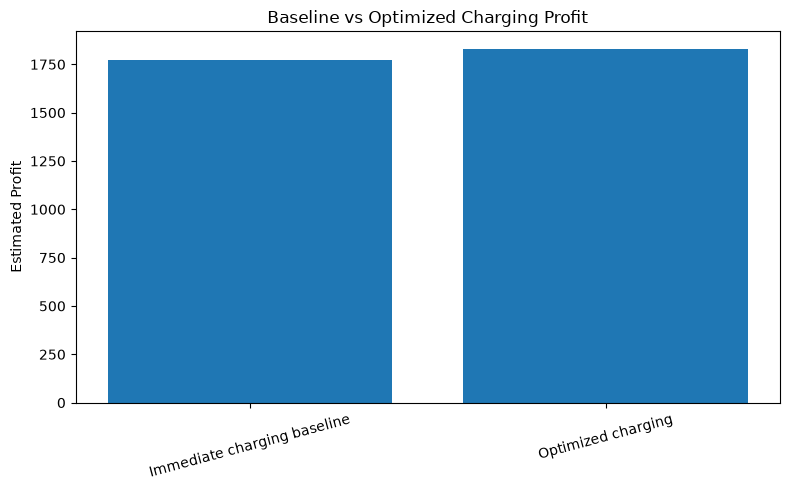

In [138]:
plt.figure(figsize=(8, 5))
plt.bar(
    verification["Strategy"],
    verification["EstimatedProfit"],
)
plt.title("Baseline vs Optimized Charging Profit")
plt.ylabel("Estimated Profit")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "08_baseline_vs_optimized.png", dpi=200)
plt.show()

## 12. Verifying That ML Predictions Improve Decisions

This section checks whether the demand forecast is actually useful for decisions, not just accurate on
paper: does it flag the same "busy" hours as what really happened?

In [139]:
verification_ts = test_ts[["TotalDemand"]].copy()

In [140]:
verification_ts["PredictedDemand"] = best_prediction

Call the busiest 25% of hours "peak hours", using actual vs predicted demand separately, then see how often they agree.

In [141]:
actual_threshold = verification_ts["TotalDemand"].quantile(0.75)

In [142]:
predicted_threshold = verification_ts["PredictedDemand"].quantile(0.75)

In [143]:
verification_ts["ActualPeak"] = (
    verification_ts["TotalDemand"] >= actual_threshold
).astype(int)

In [144]:
verification_ts["PredictedPeak"] = (
    verification_ts["PredictedDemand"] >= predicted_threshold
).astype(int)

In [145]:
peak_accuracy = (
    verification_ts["ActualPeak"] == verification_ts["PredictedPeak"]
).mean()

In [146]:
print(f"Peak-period classification agreement: {peak_accuracy:.2%}")

Peak-period classification agreement: 85.58%


In [147]:
verification_ts.to_csv(OUTPUT_DIR / "prediction_decision_verification.csv")

## 13. Project Summary

In [148]:
summary = {
    "OriginalRows": int(pd.read_csv(DATA_PATH).shape[0]),
    "CleanedRows": int(len(df)),
    "UniqueUsers": int(df["UserID"].nunique()),
    "UniqueChargers": int(df["ChargerID"].nunique()),
    "Locations": int(df["Location"].nunique()),
    "BestRegressionModel": best_model_name,
    "BestRegressionRMSE": float(results_df.iloc[0]["RMSE"]),
    "BestRegressionMAE": float(results_df.iloc[0]["MAE"]),
    "BestRegressionR2": float(results_df.iloc[0]["R2"]),
    "BestClusterK": best_k,
    "BestClusterSilhouette": float(cluster_scores["SilhouetteScore"].max()),
}

In [149]:
pd.Series(summary).to_csv(
    OUTPUT_DIR / "project_summary.csv",
    header=["Value"],
)

In [150]:
for key, value in summary.items():
    print(f"{key}: {value}")

OriginalRows: 72856
CleanedRows: 72296
UniqueUsers: 2335
UniqueChargers: 2116
Locations: 14
BestRegressionModel: Random Forest
BestRegressionRMSE: 78.95583081859547
BestRegressionMAE: 57.81459433256183
BestRegressionR2: 0.6731400285225209
BestClusterK: 2
BestClusterSilhouette: 0.440190605381712


In [151]:
print(f"All outputs have been saved to: {OUTPUT_DIR.resolve()}")

All outputs have been saved to: C:\Users\autho\Downloads\AAI-501-Group-3-EV-Charging-And-Revenue-Optimization\ev_project_output


### Academic interpretation

1. Regression predicts future hourly charging demand.
2. K-Means identifies different charging-user behaviors.
3. Time-series features capture temporal demand patterns.
4. Dynamic pricing is a transparent simulation assumption.
5. The MILP turns predictions and assumptions into actual charging decisions.
6. Held-out data verifies predictive performance.
7. The baseline-vs-optimized comparison verifies the operational benefit.